In [1]:
print("hi")

hi


In [11]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [46]:
#defining the state for the graph
class batsman_state(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int
    sr:float
    bpb:float # balls per boundary
    bp:float # boundary percentage

In [47]:
# defining the graph
graph=StateGraph(batsman_state)


In [48]:
def strike_rate(state:batsman_state):
    runs=state['runs']
    balls=state['balls']
    sr=(runs/balls)*100

    return {'sr':sr}

def balls_per_boundary(state:batsman_state):
    balls=state['balls']
    fours=state['fours']
    sixes=state['sixes']
    bpb=(balls/(fours+sixes))

    return {"bpb":bpb}

def boundary_percentage(state:batsman_state):
    runs=state['runs']
    fours=state['fours']
    sixes=state['sixes']
    bp=(((fours*4)+(sixes*6))/runs)*100

    return {'bp':bp}


In [49]:
# defining the nodes and edges of the graph

graph.add_node("strike_rate",strike_rate)
graph.add_node("balls_per_boundary",balls_per_boundary)
graph.add_node("boundary_percentage",boundary_percentage)

graph.add_edge(START,'strike_rate')
graph.add_edge(START,'balls_per_boundary')
graph.add_edge(START,'boundary_percentage')

graph.add_edge('strike_rate',END)
graph.add_edge('balls_per_boundary',END)
graph.add_edge('boundary_percentage',END)

#graph.add_edge(['strike_rate','balls_per_boundary','boundary_percentage'],END)

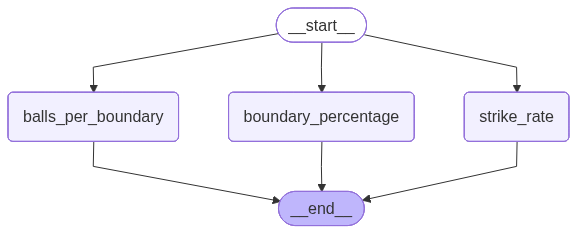

In [50]:
#defining the workflow by compiling the graph

workflow=graph.compile()
workflow

In [51]:
initial_state={'runs':100,'balls':50,'fours':6,'sixes':6}

output=workflow.invoke(initial_state)

print(output)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 6, 'sr': 200.0, 'bpb': 4.166666666666667, 'bp': 60.0}


In [52]:
state=batsman_state(**output)
print(state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 6, 'sr': 200.0, 'bpb': 4.166666666666667, 'bp': 60.0}
